## Premier League Usage Rates

#### Data Scraping
The data for this project will come from two sources, Sofascore and WhoScored. It will use ScraperFC to obtain player and team total stats over the 2025/26 season. However, this data is incomplete for the purpose of this project. The objective was to plot how Shot Creating Actions (SCA) vary with Possession Ending Actions but Sofascore does not provide SCA statistics. The solution to this problem was scraping match event data from WhoScored. The Soccerdata package enabled the collection of this data and then SCA were to be calculated manually, providing a complete data set for the rest of the project.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

In [ ]:
# Load the scraping function 
from scraping import data_scraper

# Call the function using the Whoscored and Sofascore league and season codes
data_scraper("ENG-Premier League", "25-26", "England Premier League", "25/26")

### The data
There are three data scources used to construct this project, scraped from Sofascore and WhoScored.  
- event-data-25-26 which contains event level data for all matches in the 2025/26 season. 
- player_stats_25/26 which contains detailed player level metrics for all players appearing in the Premier League across the 2025/26 season.
- team_stats_25/26 which contains detailed team level metrics for the 2025/26 season.
- player_details which contains basic player information for all players appearing in the Premier league across the 2025/26 season. This extra data sheet was needed for its detailed player position information.

Before proceeding with the analysis we will clean the data to create one player level data sheet with everything needed. The main challenge of this will be to itterate through the event data to identify and assign all SCA.

In [3]:
# Load the scraping function 
from cleaning import data_cleaning
import pandas as pd

# Initiate folders 
project_folder = Path.cwd().parent 
raw_data_folder = project_folder / "data" / "raw"

# Load raw data
event_data = pd.read_csv(raw_data_folder/"event-data-25-26.csv")
player_data = pd.read_csv(raw_data_folder/"player_data.csv")
team_data = pd.read_csv(raw_data_folder/"team_stats.csv")
player_details = pd.read_csv(raw_data_folder/"player_details.csv")

# Run the cleaning function
player_data_cleaned, team_data_cleaned = data_cleaning(event_data, player_data, team_data, player_details)

No duplicate IDs in player_stats
No duplicate IDs in player_details
All IDs in player_stats have a corresponding ID in player_details
Players in player_stats:  537
Players in player_details:  537
All teams are accounted for
positions_detailed
<class 'str'>    536
Name: count, dtype: int64
positions_detailed
<class 'list'>    536
Name: count, dtype: int64


### Shot Creating Actions
The main challenge of this section is identifying the SCA. We have all event data over the 25/26 season with over 577,000 entries. Before beginning extracting SCA from this data we must first define what a SCA actually is. OPTA defines it as the two offesnive actions directly proceeding a shot. Therfore, for each shot two players can be credited with a SCA, whether it is a driblle, tackle, pass or anything else. Once the SCAs have been identified, we want to extract this data to finish with a dataframe containing all players in the league and their SCA numbers over the whole season. 

In [4]:
# Load the SCA calculating functions
from sca import calculate_sca_for_season, create_sca_dataframe

# Calculate all SCAs for the 25/26 Prem season
all_sca_results_df = calculate_sca_for_season(event_data)

# Make DF and save
sca_df = create_sca_dataframe(all_sca_results_df)

### Usage Metrics
We can now define the methodology of our investigation. First we will consider observable actions that can result in a possession ending. This can be a shot on goal, an inaccurate pass, a player being dispossessed, an unsuccessful dribble or a miscontrol. The sum of these will define a player's total number of Possession Ending Actions (PEA). This data was obtainable over the 25/26 season, with the exception of miscontrols. Therefore, a player's PEA will be calculated as such:
$$\text{PEA} = \text{Shots} + \text{Inaccurate Passes} + \text{Dispossessed} + \text{Unsuccessful Dribbles} $$
Since not all players across the league play an even amount of minutes, the PEA values are normalised for minutes played to create a player's PEA/90:
$$\text{PEA / 90} = \frac{\text{PEA}}{\text{Minutes Played}} \times 90 $$

Since this investigation aims to evaluate how well players use the ball given their share of PEA, we need a metric to define output. Shot Creating Actions (SCA) are the perfect metric, defined as the two offensive actions immediately proceeding a shot. This is a really useful metric since it credits secondary actions like an interception or take on which leads to a pass leading to a shot, therefore giving a better view of a player's offensive contribution. We have now been able to manually count SCA thanks to the soccerdata package which allowed us to scrape event data from all 380 games across the 2025/26 season. Using this data, we created an algorithm to manually identify each shot taken across the season and then identify the direct and secondary SCAs when applicable, storing their type as well. This will allow a better analysis how how well players use the ball than our previous analysis which relied on direct chances created. 

The limitation with the current framework is that it is hard to compare PEA / 90 and SCA / 90 across all teams in the league due to possession. Players on teams with greater average possession generally have more opportunity to become involved in possession ending actions and chance creation. For example, Rayan Cherki might have higher PEA / 90 and SCA / 90 stats than a player like Harry Wilson since it is likely that Manchester City will on average see a much higher share of possesion than Fulham so these stats are not immediately informative. We will therefore assume that player involvement scales linearly with team possesion and normalise so that each team has a neutral 50% possession share, adjusting the stats as such:
$$\text{PEA / 90}_{\text{adj}} = \text{PEA / 90} \times \frac{50}{\text{Team Possession}}$$
$$\text{SCA / 90}_{\text{adj}} = \text{SCA / 90} \times \frac{50}{\text{Team Possession}}$$

At this point we will be able to make a fair comparison of all players across the league and identify how SCA / 90 varies with PEA / 90 across different groups of positions.

To investigate a player's role within their own team, we want to look at how much of a team's possession flow through a single player and how much of the team's total output can be attributed to that player. Since we will not be considering goalkeepers in this analysis, the total team PEA and SCA will be calculated as the sum of all elgible outfield players:
$$\text{Team PEA} = \sum{\text{Total Player PEA}}$$
$$\text{Team SCA} = \sum{\text{Total Player SCA}}$$

Then we can define a new metric, a player's Usage Rate, which is the proportion of team possessions that end with that player:
$$\text{Usage Rate} = \frac{\text{Player PEA}}{\text{Team PEA}}$$
We can also find a player's Attacking Involvement as:
$$\text{Attacking Involvement} = \frac{\text{Player SCA}}{\text{Team SCA}}$$

Plotting these two metrics against each other, we will be able to identify a player's importance within their team and compare it to their output, creating one final metric, Relative Creation Efficiency (RCE):
$$\text{RCE} = \frac{\text{Attacking Involvement}}{\text{Usage Rate}}$$

From this analysis we will be able to measure the standout players across the league and also the most important players within specific teams.

In [6]:
from metrics import find_name_mismatches, calculate_metrics

# Find mismatching names
mismatching_names = find_name_mismatches(player_data_cleaned, sca_df)
print(mismatching_names)

# Create a player name map
name_mapping = {
    "Josko Gvardiol" : "Joško Gvardiol",
    "Callum Hudson-Odoi" : "Callum Hudson Odoi",
    "Daniel Ballard" : "Dan Ballard",
    "Mateo Kovacic" : "Mateo Kovačić",
    "Idrissa Gueye" : "Idrissa Gana Gueye",
    "Ferdi Kadioglu" : "Ferdi Kadıoğlu",
    "Nikola Milenkovic" : "Nikola Milenković",
    "Junior Kroupi" : "Eli Junior Kroupi",
    "Benjamin Sesko" : "Benjamin Šeško",
    "Tomás Soucek" : "Tomáš Souček",
    "Ladislav Krejcí" : "Ladislav Krejčí",
    "Florentino" : "Florentino Luís",
    "Vitalii Mykolenko" : "Vitaliy Mykolenko",
    "Fábio Carvalho" : "Fabio Carvalho",
    "Sasa Lukic" : "Saša Lukić",
    "Jair Cunha" : "Jair",
    "Josh King" : "Joshua King",
    "Milos Kerkez" : "Miloš Kerkez",
    "Hwang Hee-Chan" : "Hwang Hee-chan",
    "Ollie Scarles" : "Oliver Scarles",
    "Maximilian Kilman" : "Max Kilman",
    "Radu Dragusin" : "Radu Drăguşin",
    "Hamed Traoré" : "Hamed Junior Traorè",
    "Charly Alcaraz" : "Carlos Alcaraz"}

# Calculate metrics
usage_data = calculate_metrics(player_data_cleaned, team_data_cleaned, sca_df, name_mapping = name_mapping)

            playerName       possibleMatch
0           Tom Edozie                 NaN
1       Joško Gvardiol      Josko Gvardiol
2         Jenson Seelt                 NaN
3   Callum Hudson Odoi  Callum Hudson-Odoi
4       Daniel Ballard         Dan Ballard
..                 ...                 ...
66         Emil Krafth                 NaN
67      James Rowswell                 NaN
68  Myles Peart-Harris                 NaN
69     Nehemiah Oriola                 NaN
70          Joe Knight                 NaN

[71 rows x 2 columns]


### League Analysis

We now have data for all eligible Premier League players in the 2025/26 season across four key metrics: Possession Ending Actions per 90 (PEA/90), both raw and possession adjusted; Shot Creating Actions per 90 (SCA/90), both raw and possession adjusted; Usage Rate; and Attacking Involvement. To begin the analysis, we will examine four positional groups: wingers, strikers, midfielders and fullbacks. For each group, PEA/90 will be compared against SCA/90 using both the raw and possession-adjusted metrics. Each data point will also be scaled according to the player's combined goals and assists (G+A), providing a third dimension that represents their direct goal involvement.

PEA provides a measure of a player's involvement in possession-ending actions, while SCA provides a measure of their creative output. Comparing these metrics across both raw and possession-adjusted data will allow us to investigate how a player's creative output relates to the amount of possession available to them and identify differences between positional groups.

From the resulting figures, we can identify players who combine high involvement with high creative output, while also considering their direct goal involvement and the possession context of their team.

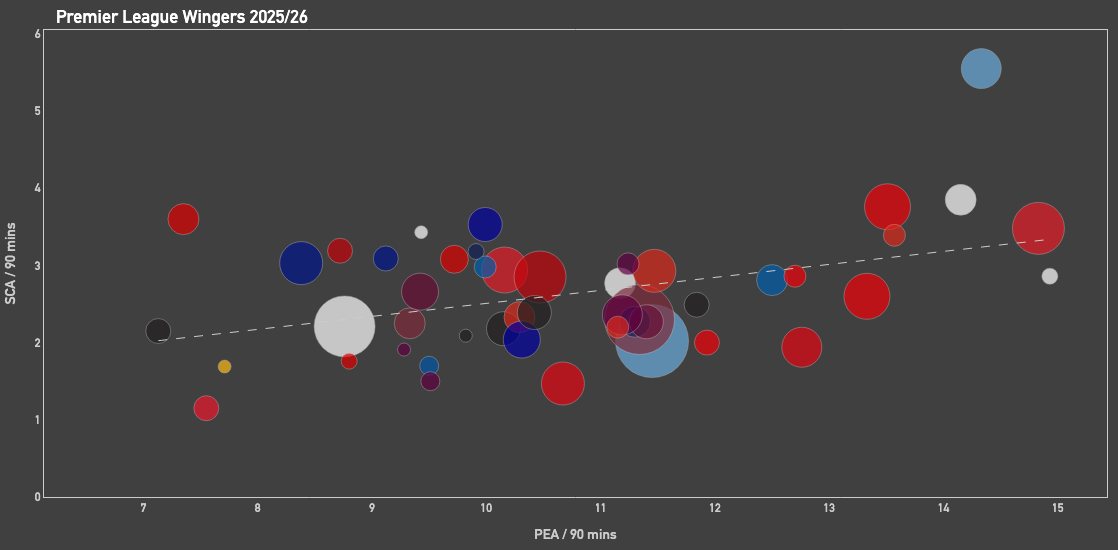

In [7]:
from plotting import plot_positions, plot_team

# Define kit colours for each premier league team
kit_map = {
    42 : "#EF0107",
    34 : "#FFFFFF",
    30 : "#005DAA",
    50 : "#E30613",
    41 : "#EB172B",
    60 : "#DA291C",
    40 : "#670e36",
    14 : "#DD0000",
    3 : "#FDB913",
    17 : "#6CADDF",
    43 : "#FFFFFF",
    37 : "#7C2C3B",
    33 : "#132257",
    7 : "#0055A5",
    35 : "#C1040B",
    38 : "#001489",
    6 : "#5F0041",
    48 : "#00009E",
    39 : "#231F20",
    44 : "#E51C25"}

# plot for wingers
plot_positions(usage_data, "Winger", kit_map, 900, interactive = True)

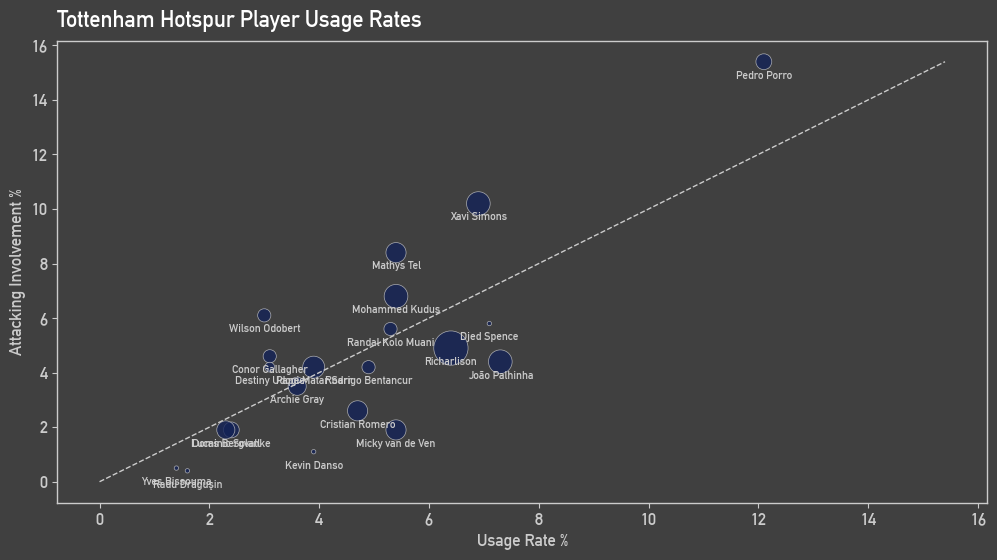

In [15]:
plot_team(usage_data, "Tottenham Hotspur", "#132257")